In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from scipy.stats import norm
from scipy.signal import hilbert
np.random.seed(42)

In [ ]:
# Synthetic Data creation
grid_size_x, grid_size_y = 100, 100
x_coords = np.linspace(0, 10, grid_size_x)
y_coords = np.linspace(0, 10, grid_size_y)
X, Y = np.meshgrid(x_coords, y_coords)

def generate_sp_data(X, Y):
    return 0.1 * (np.sin(0.5 * X) * np.cos(0.5 * Y))

def add_anomaly(data, center_x, center_y, strength, spread):
    for i in range(grid_size_x):
        for j in range(grid_size_y):
            distance = np.sqrt((X[i, j] - center_x)**2 + (Y[i, j] - center_y)**2)
            data[i, j] += strength * np.exp(-distance**2 / (2 * spread**2))
    return data

sp_data = generate_sp_data(X, Y)
sp_data = add_anomaly(sp_data, 3, 7, -2, 0.5)
sp_data = add_anomaly(sp_data, 7, 4, 1.75, 0.75)
sp_data = add_anomaly(sp_data, 5, 5, -1.45, 1)

# Adiing noise to the data()
noise_amt=0.02
noise_level = noise_amt * np.max(sp_data)
noise = noise_level * np.random.randn(grid_size_x, grid_size_y)
sp_data_noisy = sp_data + noise

In [ ]:
# To decide the hyperparameters
def pso_objective(params):
    x0, y0, q = params
    fitted_sp = np.zeros((grid_size_x, grid_size_y))
    for i in range(grid_size_x):
        for j in range(grid_size_y):
            distance = np.sqrt((X[i, j] - x0)**2 + (Y[i, j] - y0)**2)
            fitted_sp[i, j] += q / (distance + 1e-6)
    error = np.sum((fitted_sp - sp_data_noisy) ** 2) + np.sum((fitted_sp[fitted_sp > 0]) ** 2)
    return error

bounds = [(0, 10), (0, 10), (-10, 10)]
#Using built-in method for locating the Anomaly by PSO
result = differential_evolution(pso_objective, bounds)

In [ ]:
latitude, longitude = (result.x[1] / 10) * 180 - 90, (result.x[0] / 10) * 360 - 180
print(f"Detected probable water deposit near: Latitude = {latitude:.4f}, Longitude = {longitude:.4f}")

Detected probable water deposit near: Latitude = 34.5513, Longitude = -69.1197


In [ ]:
# COP
def calculate_cop(sp_data_noisy, sp_data, noise_level):
    prob_density = norm.pdf(sp_data_noisy, loc=sp_data, scale=noise_level)
    cop = prob_density / np.max(prob_density)
    return cop

charge_probability = calculate_cop(sp_data_noisy, sp_data, noise_level)

In [ ]:
def calculate_analytical_signal(data):
    analytical_signal = hilbert(data)
    amplitude_envelope = np.abs(analytical_signal)
    return amplitude_envelope

analytical_signal = calculate_analytical_signal(sp_data_noisy[grid_size_y // 2, :])

In [ ]:
# Deth is now considered for detailed sub-surface charactarization and study of charge distribution
depths = np.linspace(0, 5, 50)
Z, Y_grid, X_grid = np.meshgrid(depths, y_coords, x_coords)

#COP on 3d
def cop3D(charge_probability_2d):
    cop_3d = np.zeros((len(depths), grid_size_y, grid_size_x))
    for k, depth in enumerate(depths):
        decay = np.exp(-depth)
        cop_3d[k, :, :] = charge_probability_2d * decay
    return cop_3d

cop_3d = cop3D(charge_probability)

Detected probable water deposit near: Latitude = 34.5513, Longitude = -69.1197


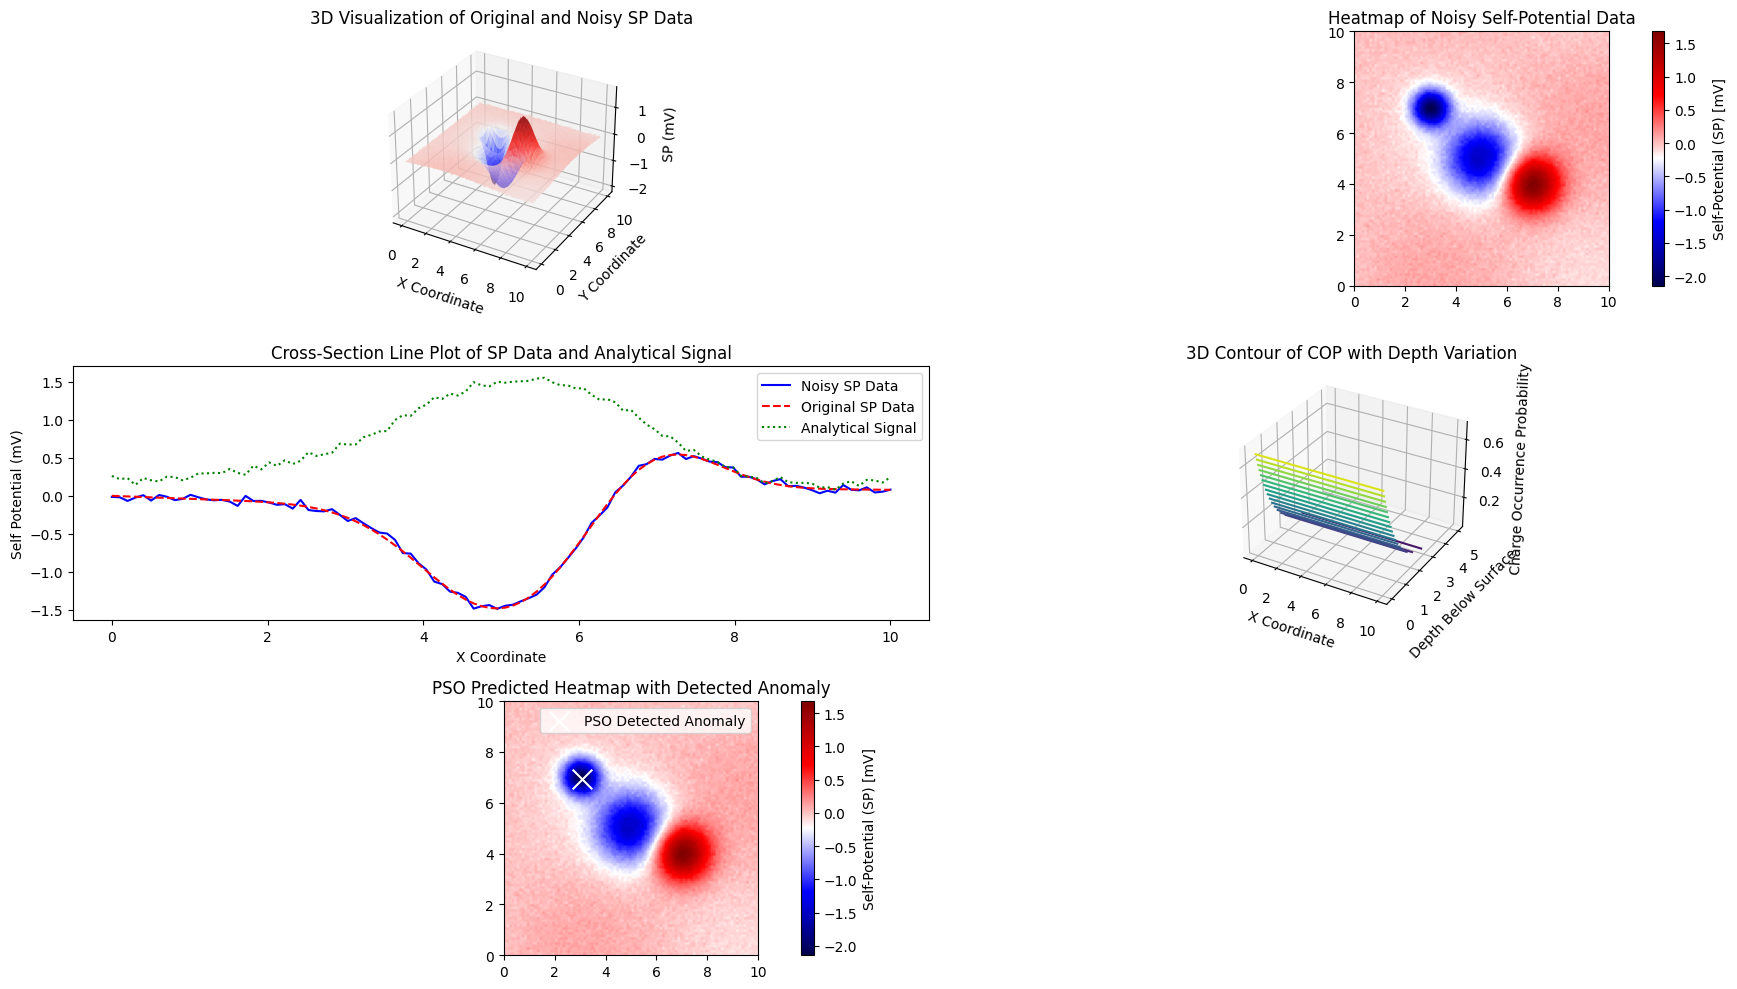

In [ ]:
print(f"Detected probable water deposit near: Latitude = {latitude:.4f}, Longitude = {longitude:.4f}")

#Plotting the required curves
fig = plt.figure(figsize=(18, 10))

# 3D Visualization of Original and Noisy SP Data
ax1 = fig.add_subplot(3, 2, 1, projection='3d')
ax1.plot_surface(X, Y, sp_data, cmap='seismic', edgecolor='none', alpha=0.5)
ax1.plot_surface(X, Y, sp_data_noisy, cmap='coolwarm', edgecolor='none', alpha=0.7)
ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')
ax1.set_zlabel('SP (mV)')
ax1.set_title('3D Visualization of Original and Noisy SP Data')

# Heat Map of Noisy SP Data
plt.subplot(3, 2, 2)
plt.imshow(sp_data_noisy, extent=(0, 10, 0, 10), origin='lower', cmap='seismic')
plt.colorbar(label='Self-Potential (SP) [mV]')
plt.title("Heatmap of Noisy Self-Potential Data")

# Cross-Section Line Plot of SP Data and Analytical Signal
plt.subplot(3, 2, 3)
plt.plot(x_coords, sp_data_noisy[grid_size_y // 2, :], label='Noisy SP Data', color='b')
plt.plot(x_coords, sp_data[grid_size_y // 2, :], label='Original SP Data', color='r', linestyle='--')
plt.plot(x_coords, analytical_signal, label='Analytical Signal', color='g', linestyle=':')
plt.xlabel("X Coordinate")
plt.ylabel("Self Potential (mV)")
plt.title("Cross-Section Line Plot of SP Data and Analytical Signal")
plt.legend()

# 3D Contour Plot of Charge Occurrence Probability with Depth
ax2 = fig.add_subplot(3, 2, 4, projection='3d')
cop_z = np.mean(cop_3d, axis=(1, 2))
X_depth, Z_depth = np.meshgrid(x_coords, depths)
ax2.contour3D(X_depth, Z_depth, np.tile(cop_z, (grid_size_x, 1)).T, levels=20, cmap='viridis')
ax2.set_xlabel('X Coordinate')
ax2.set_ylabel('Depth Below Surface')
ax2.set_zlabel('Charge Occurrence Probability')
ax2.set_title('3D Contour of COP with Depth Variation')

# PSO Predicted Heatmap with Detected Anomaly
plt.subplot(3, 2, 5)
plt.imshow(sp_data_noisy, extent=(0, 10, 0, 10), origin='lower', cmap='seismic')
plt.colorbar(label='Self-Potential (SP) [mV]')
plt.scatter(result.x[0], result.x[1], color='white', marker='x', s=200, label='PSO Detected Anomaly')
plt.title("PSO Predicted Heatmap with Detected Anomaly")
plt.legend()

fig.tight_layout()
plt.show()